<a href="https://colab.research.google.com/github/lucianotadeu/processamento_Imagens_OpenCV_SciPy/blob/main/Processamento_Imagens_OpenCV_SciPy_4%C2%AA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**colab - Disciplina Processamento de imagem e sinais - FMU 2026.01**
*  Professor Luciano Tadeu Pereira
* email luciano.tadeu@fmu.br

---

**ATENÇÃO**: Antes de começar, faça uma cópia deste notebook para sua conta do Google Drive. Assim, você poderá editar e testar sem modificar o original.

Para isso, clique em "Arquivo" → "Salvar uma cópia no Drive".

OBS: Para executar este notebook, **não** é necessário um ambiente de execução com GPU.

---

# 🖼️ Processamento de Imagens e Sinais
## Disciplina: Inteligência Artificial — Tecnólogos em IA

---

**Objetivo deste notebook:**  
Apresentar as principais ferramentas e bibliotecas utilizadas no processamento de imagens, com foco em **OpenCV** e **SciPy**, explorando suas funcionalidades de forma prática e progressiva.

**Como usar:**  
Cada seção corresponde a uma **aula separada**. Execute as células em ordem, leia as explicações e experimente modificar os parâmetros para aprofundar o entendimento.

---

### 📚 Estrutura do Notebook

| Aula | Tema |
|------|------|
| Aula 1 | Introdução às Bibliotecas e Instalação |
| Aula 2 | Upload e Leitura de Imagens |
| Aula 3 | OpenCV — Leitura, Escrita e Exibição |
| Aula 4 | OpenCV — Manipulação de Imagens |
| Aula 5 | OpenCV — Filtragem de Imagens |
| Aula 6 | OpenCV — Detecção de Bordas |
| Aula 7 | OpenCV — Reconhecimento de Objetos |
| Aula 8 | SciPy — Processamento de Sinais |
| Aula 9 | SciPy — Interpolação de Imagens |
| Aula 10 | SciPy — Análise Estatística Visual |

---
# 📘 AULA 1 — Introdução às Bibliotecas e Instalação

## O que é Processamento de Imagens?

O **processamento de imagens** é uma área da computação que aplica algoritmos matemáticos e estatísticos sobre imagens digitais com o objetivo de:
- Melhorar a qualidade visual (remoção de ruídos, ajuste de brilho/contraste)
- Extrair informações relevantes (detecção de bordas, segmentação)
- Reconhecer padrões (faces, objetos, texto)

Uma imagem digital é representada como uma **matriz de pixels**. Cada pixel contém valores numéricos que representam intensidade de cor:
- **Escala de cinza**: 1 canal, valores de 0 (preto) a 255 (branco)
- **Colorida (RGB)**: 3 canais — Vermelho, Verde e Azul
- **Com transparência (RGBA)**: 4 canais

## Principais Bibliotecas

### 🔹 OpenCV (Open Source Computer Vision Library)
- Criada pela Intel em 1999, hoje mantida pela comunidade open-source
- Mais de 2.500 algoritmos otimizados para visão computacional
- Suporta Python, C++, Java
- Ideal para: manipulação de imagens/vídeos, detecção de objetos, visão em tempo real

### 🔹 SciPy (Scientific Python)
- Biblioteca científica construída sobre o NumPy
- Módulo `scipy.ndimage` especializado em processamento de imagens N-dimensionais
- Módulo `scipy.signal` para processamento de sinais
- Ideal para: análise matemática, transformadas, filtragem avançada

### 🔹 Outras bibliotecas complementares
| Biblioteca | Uso Principal |
|------------|---------------|
| **NumPy** | Operações matriciais com arrays de pixels |
| **Matplotlib** | Visualização e exibição de imagens |
| **Pillow (PIL)** | Leitura/escrita de múltiplos formatos |
| **scikit-image** | Algoritmos avançados de visão computacional |

In [ ]:
# ============================================================
# AULA 1 — Célula 1: Instalação das bibliotecas necessárias
# ============================================================
# No Google Colab, OpenCV e SciPy já vêm pré-instalados.
# Este bloco garante que temos as versões mais recentes.

!pip install opencv-python-headless scipy matplotlib numpy Pillow scikit-image --quiet

print("✅ Instalação concluída!")

✅ Instalação concluída!


In [ ]:
# ============================================================
# AULA 1 — Célula 2: Importação e verificação das versões
# ============================================================
# Boa prática: sempre verificar as versões instaladas para
# garantir reprodutibilidade dos experimentos.

import cv2
import numpy as np
import scipy
import matplotlib
import matplotlib.pyplot as plt
from PIL import Image
import skimage
import os
import urllib.request
import shutil # Adicionado para copiar o conteúdo da URL para um arquivo



print("📦 Versões das bibliotecas instaladas:")
print(f"  OpenCV   : {cv2.__version__}")
print(f"  NumPy    : {np.__version__}")
print(f"  SciPy    : {scipy.__version__}")
print(f"  Matplotlib: {matplotlib.__version__}")
print(f"  scikit-image: {skimage.__version__}")
print("\n✅ Todas as bibliotecas carregadas com sucesso!")

📦 Versões das bibliotecas instaladas:
  OpenCV   : 4.13.0
  NumPy    : 2.0.2
  SciPy    : 1.16.3
  Matplotlib: 3.10.0
  scikit-image: 0.25.2

✅ Todas as bibliotecas carregadas com sucesso!


/tmp/ipykernel_470/238589364.py:37: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


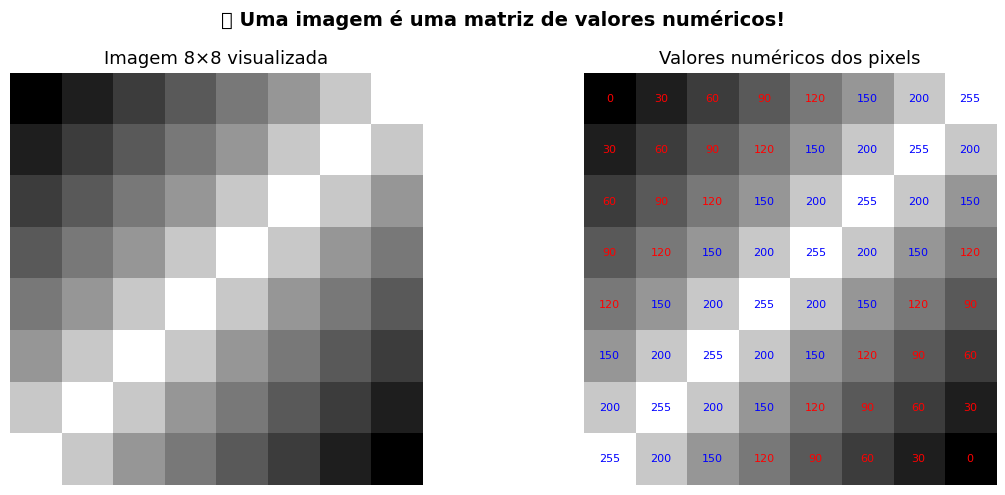


📐 Formato da matriz: (8, 8)
📊 Tipo dos dados  : uint8
🔢 Valor mínimo    : 0 (preto)
🔢 Valor máximo    : 255 (branco)


In [ ]:
# ============================================================
# AULA 1 — Célula 3: Conceito fundamental — imagem como matriz
# ============================================================
# Vamos criar uma imagem sintética simples para entender
# como pixels são representados como valores numéricos.

# Criando uma imagem 8x8 em escala de cinza (valores de 0 a 255)
imagem_exemplo = np.array([
    [  0,  30,  60,  90, 120, 150, 200, 255],
    [ 30,  60,  90, 120, 150, 200, 255, 200],
    [ 60,  90, 120, 150, 200, 255, 200, 150],
    [ 90, 120, 150, 200, 255, 200, 150, 120],
    [120, 150, 200, 255, 200, 150, 120,  90],
    [150, 200, 255, 200, 150, 120,  90,  60],
    [200, 255, 200, 150, 120,  90,  60,  30],
    [255, 200, 150, 120,  90,  60,  30,   0]
], dtype=np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Exibindo a imagem visualmente
axes[0].imshow(imagem_exemplo, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Imagem 8×8 visualizada', fontsize=13)
axes[0].axis('off')

# Exibindo os valores numéricos
axes[1].imshow(imagem_exemplo, cmap='gray', vmin=0, vmax=255)
for i in range(8):
    for j in range(8):
        axes[1].text(j, i, str(imagem_exemplo[i, j]),
                    ha='center', va='center', fontsize=8,
                    color='red' if imagem_exemplo[i, j] < 128 else 'blue')
axes[1].set_title('Valores numéricos dos pixels', fontsize=13)
axes[1].axis('off')

plt.suptitle('💡 Uma imagem é uma matriz de valores numéricos!', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n📐 Formato da matriz: {imagem_exemplo.shape}")
print(f"📊 Tipo dos dados  : {imagem_exemplo.dtype}")
print(f"🔢 Valor mínimo    : {imagem_exemplo.min()} (preto)")
print(f"🔢 Valor máximo    : {imagem_exemplo.max()} (branco)")

---
# 📘 AULA 2 — Upload e Leitura de Imagens

## Por que o Upload é importante?

No ambiente Google Colab, trabalhamos em um servidor remoto. Para processar imagens do nosso computador, precisamos **enviá-las para o ambiente de execução**.

Existem três formas principais:
1. **Upload direto** via `google.colab.files` — para arquivos locais
2. **Download de URL** — para imagens da internet
3. **Google Drive** — para arquivos já salvos na nuvem

Após o upload, aprenderemos a **inspecionar** as propriedades da imagem.

In [ ]:
# ============================================================
# AULA 2 — Célula 1: Upload de imagem do computador local
# ============================================================
# O módulo 'google.colab.files' permite fazer upload de arquivos
# diretamente do seu computador para o ambiente Colab.

from google.colab import files
import io

print("📤 Clique no botão abaixo para selecionar uma imagem do seu computador.")
print("   Formatos aceitos: .jpg, .jpeg, .png, .bmp, .tiff")
print("")

uploaded = files.upload()

# Recuperando o nome do arquivo enviado
nome_arquivo = list(uploaded.keys())[0]
print(f"\n✅ Arquivo recebido: '{nome_arquivo}'")
print(f"   Tamanho: {len(uploaded[nome_arquivo]) / 1024:.2f} KB")

📤 Clique no botão abaixo para selecionar uma imagem do seu computador.
   Formatos aceitos: .jpg, .jpeg, .png, .bmp, .tiff



Saving Sem título.jpg to Sem título.jpg

✅ Arquivo recebido: 'Sem título.jpg'
   Tamanho: 41.05 KB


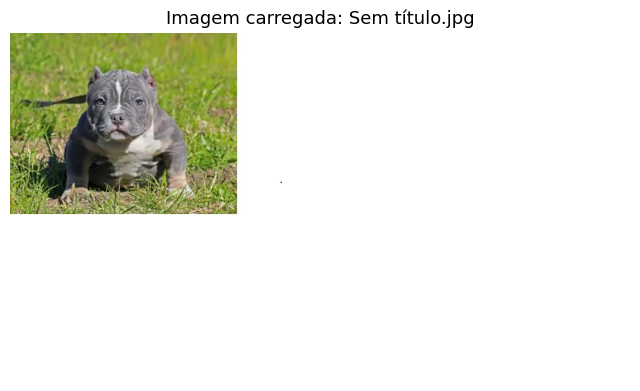


📊 PROPRIEDADES DA IMAGEM:
  📐 Dimensões      : 819 × 460 pixels
  🎨 Canais de cor  : 3 (B, G, R)
  💾 Tipo de dados  : uint8
  🔢 Total de pixels: 376,740
  💿 Tamanho em memória: 1103.73 KB


In [ ]:
# ============================================================
# AULA 2 — Célula 2: Carregando e inspecionando a imagem
# ============================================================
# Após o upload, carregamos a imagem com OpenCV e analisamos
# suas propriedades fundamentais.

# Lendo a imagem carregada
imagem_bytes = np.frombuffer(uploaded[nome_arquivo], dtype=np.uint8)
imagem_bgr = cv2.imdecode(imagem_bytes, cv2.IMREAD_COLOR)

# OpenCV usa ordem BGR (Azul, Verde, Vermelho) por padrão
# Matplotlib usa ordem RGB, então precisamos converter para exibição correta
imagem_rgb = cv2.cvtColor(imagem_bgr, cv2.COLOR_BGR2RGB)

# Exibindo a imagem
plt.figure(figsize=(8, 6))
plt.imshow(imagem_rgb)
plt.title(f'Imagem carregada: {nome_arquivo}', fontsize=13)
plt.axis('off')
plt.show()

# Inspecionando as propriedades
altura, largura, canais = imagem_bgr.shape
print("\n📊 PROPRIEDADES DA IMAGEM:")
print(f"  📐 Dimensões      : {largura} × {altura} pixels")
print(f"  🎨 Canais de cor  : {canais} (B, G, R)")
print(f"  💾 Tipo de dados  : {imagem_bgr.dtype}")
print(f"  🔢 Total de pixels: {largura * altura:,}")
print(f"  💿 Tamanho em memória: {imagem_bgr.nbytes / 1024:.2f} KB")

✅ Arquivo baixado: 'imagem_teste.png'


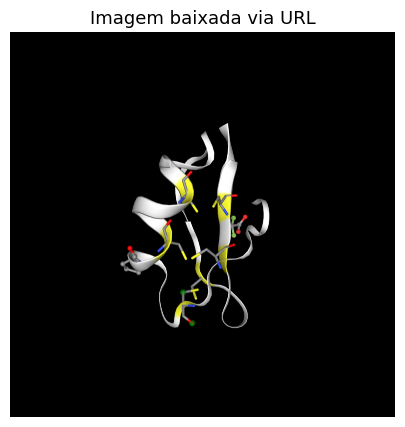

✅ Imagem baixada com sucesso! Dimensões: (6618, 6618, 3)

💡 Dica: Para usar sua própria imagem nas próximas aulas,
   substitua a variável 'imagem_bgr' pela imagem de sua preferência.


In [ ]:
# ============================================================
# AULA 2 — Célula 3 (Alternativa): Download de imagem via URL
# ============================================================
# Caso não queira fazer upload manual, podemos baixar uma imagem
# diretamente da internet usando urllib.

# URL de uma imagem de exemplo (paisagem de domínio público)
url_imagem = "https://upload.wikimedia.org/wikipedia/commons/e/e7/OdK2_toxin_disulfide_bonds.png"


# Adicionando um User-Agent para evitar o erro 403 Forbidden
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'}
req = urllib.request.Request(url_imagem, headers=headers)

try:
    with urllib.request.urlopen(req) as response, open("imagem_teste.png", 'wb') as out_file:
        shutil.copyfileobj(response, out_file)
    print(f"✅ Arquivo baixado: 'imagem_teste.png'")

    # Carregando com OpenCV
    imagem_url = cv2.imread("imagem_teste.png")
    if imagem_url is None:
        print("❌ Não foi possível carregar a imagem com OpenCV. O arquivo pode estar corrompido ou o formato não é suportado.")
    else:
        imagem_url_rgb = cv2.cvtColor(imagem_url, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(6, 5))
        plt.imshow(imagem_url_rgb)
        plt.title('Imagem baixada via URL', fontsize=13)
        plt.axis('off')
        plt.show()

        print(f"✅ Imagem baixada com sucesso! Dimensões: {imagem_url.shape}")
        print("\n💡 Dica: Para usar sua própria imagem nas próximas aulas,")
        print("   substitua a variável 'imagem_bgr' pela imagem de sua preferência.")

except urllib.error.HTTPError as e:
    print(f"❌ Erro HTTP ao baixar a imagem: {e}")
    print("Este erro (403 Forbidden) geralmente significa que o servidor bloqueou a requisição automática.")
    print("Por favor, verifique a URL ou tente novamente mais tarde.")
except Exception as e:
    print(f"❌ Ocorreu um erro inesperado ao baixar a imagem: {e}")

---
# 📘 AULA 3 — OpenCV: Leitura, Escrita e Exibição

## Operações Fundamentais com Imagens

Antes de qualquer processamento avançado, precisamos dominar as operações básicas:
- **Leitura**: Carregar imagens do disco em memória
- **Exibição**: Visualizar imagens durante o desenvolvimento
- **Escrita**: Salvar resultados processados
- **Conversão de espaços de cor**: Trabalhar com diferentes representações

### ⚠️ Atenção: BGR vs RGB
OpenCV armazena imagens no formato **BGR** (Blue-Green-Red), enquanto a maioria das outras ferramentas usa **RGB**. Esse é um dos erros mais comuns entre iniciantes!

/tmp/ipykernel_470/48719101.py:40: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


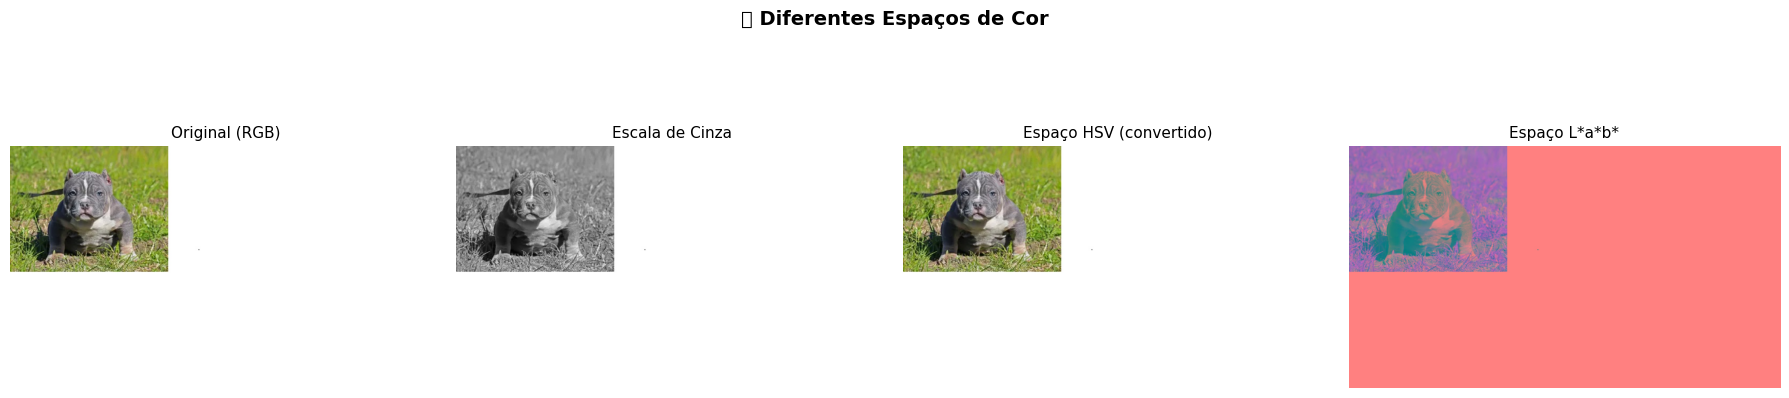


📚 Quando usar cada espaço de cor?
  RGB  → Exibição e processamento geral
  Cinza → Algoritmos que não precisam de cor (mais rápido e eficiente)
  HSV  → Segmentação por cor (ex: detectar objetos de cor específica)
  LAB  → Comparação perceptual de cores (mais próxima da visão humana)


In [ ]:
# ============================================================
# AULA 3 — Célula 1: Leitura e conversão de espaços de cor
# ============================================================

# Usaremos a imagem carregada na Aula 2.
# Se precisar de uma imagem padrão, execute a célula da Aula 2 primeiro.
# Aqui vamos usar 'imagem_bgr' como referência.

try:
    img = imagem_bgr.copy()
except NameError:
    img = cv2.imread("imagem_teste.png")
    print("ℹ️  Usando imagem de teste. Execute a Aula 2 para usar sua própria imagem.")

# Convertendo para diferentes espaços de cor
img_rgb   = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)   # Para exibição correta
img_gray  = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  # Escala de cinza
img_hsv   = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)   # Matiz, Saturação, Valor
img_lab   = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)   # Espaço perceptual L*a*b*

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(img_rgb)
axes[0].set_title('Original (RGB)', fontsize=11)
axes[0].axis('off')

axes[1].imshow(img_gray, cmap='gray')
axes[1].set_title('Escala de Cinza', fontsize=11)
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(img_hsv, cv2.COLOR_HSV2RGB))
axes[2].set_title('Espaço HSV (convertido)', fontsize=11)
axes[2].axis('off')

axes[3].imshow(img_lab)
axes[3].set_title('Espaço L*a*b*', fontsize=11)
axes[3].axis('off')

plt.suptitle('🎨 Diferentes Espaços de Cor', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📚 Quando usar cada espaço de cor?")
print("  RGB  → Exibição e processamento geral")
print("  Cinza → Algoritmos que não precisam de cor (mais rápido e eficiente)")
print("  HSV  → Segmentação por cor (ex: detectar objetos de cor específica)")
print("  LAB  → Comparação perceptual de cores (mais próxima da visão humana)")

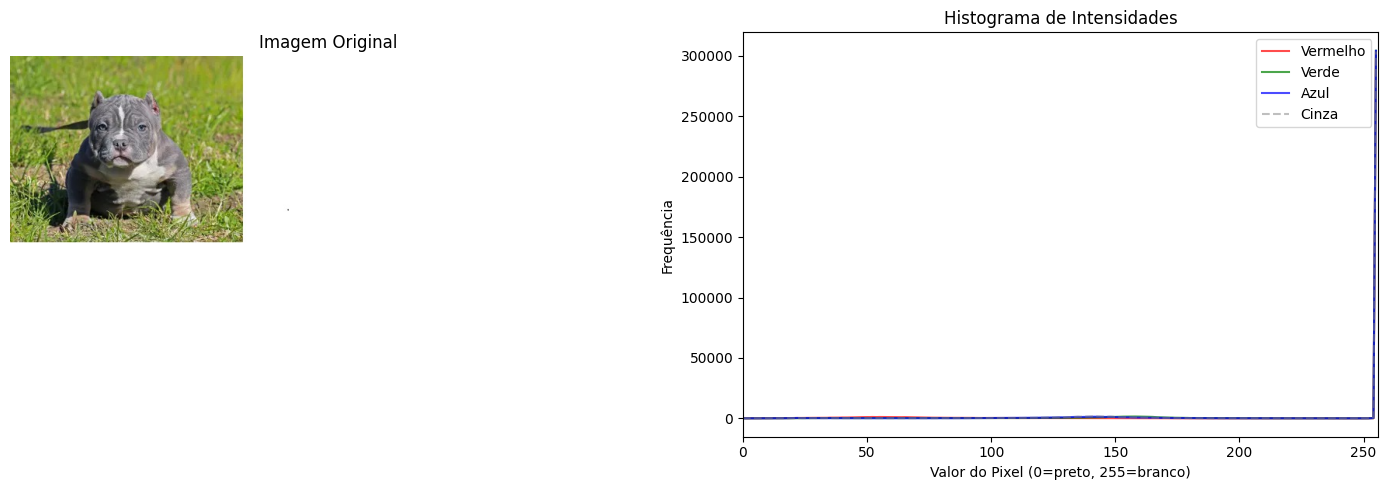

💡 Interpretando o histograma:
  → Pico à esquerda: imagem escura
  → Pico à direita: imagem clara (superexposta)
  → Distribuição central e equilibrada: boa exposição


In [ ]:
# ============================================================
# AULA 3 — Célula 2: Histograma de cores
# ============================================================
# O histograma mostra a distribuição dos valores de intensidade.
# É uma ferramenta diagnóstica fundamental em processamento de imagens.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Imagem original
axes[0].imshow(img_rgb)
axes[0].set_title('Imagem Original', fontsize=12)
axes[0].axis('off')

# Histograma dos canais
cores = ('r', 'g', 'b')
nomes = ('Vermelho', 'Verde', 'Azul')
for i, (cor, nome) in enumerate(zip(cores, nomes)):
    hist = cv2.calcHist([img], [i], None, [256], [0, 256])
    axes[1].plot(hist, color=cor, label=nome, alpha=0.7)

# Histograma em cinza
hist_gray = cv2.calcHist([img_gray], [0], None, [256], [0, 256])
axes[1].plot(hist_gray, color='gray', label='Cinza', linestyle='--', alpha=0.5)

axes[1].set_title('Histograma de Intensidades', fontsize=12)
axes[1].set_xlabel('Valor do Pixel (0=preto, 255=branco)')
axes[1].set_ylabel('Frequência')
axes[1].legend()
axes[1].set_xlim([0, 256])

plt.tight_layout()
plt.show()

print("💡 Interpretando o histograma:")
print("  → Pico à esquerda: imagem escura")
print("  → Pico à direita: imagem clara (superexposta)")
print("  → Distribuição central e equilibrada: boa exposição")

In [ ]:
# ============================================================
# AULA 3 — Célula 3: Salvando imagens processadas
# ============================================================

# Salvando a versão em escala de cinza
cv2.imwrite('imagem_cinza.jpg', img_gray)
cv2.imwrite('imagem_original.png', img)

print("💾 Imagens salvas no ambiente Colab:")
print("  → imagem_cinza.jpg")
print("  → imagem_original.png")

# Para fazer download das imagens salvas:
from google.colab import files
files.download('imagem_cinza.jpg')

print("\n📌 Para baixar o arquivo, descomente as linhas acima.")

💾 Imagens salvas no ambiente Colab:
  → imagem_cinza.jpg
  → imagem_original.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📌 Para baixar o arquivo, descomente as linhas acima.


---
# 📘 AULA 4 — OpenCV: Manipulação de Imagens

## Transformações Geométricas

As transformações geométricas alteram a **posição, tamanho ou orientação** dos pixels sem modificar seus valores de intensidade. São operações fundamentais para:
- Padronizar o tamanho de imagens em datasets de Machine Learning
- Realizar data augmentation (aumento artificial de dados)
- Corrigir perspectiva ou orientação de imagens capturadas

Matematicamente, cada transformação é representada por uma **matriz de transformação** aplicada sobre as coordenadas dos pixels.

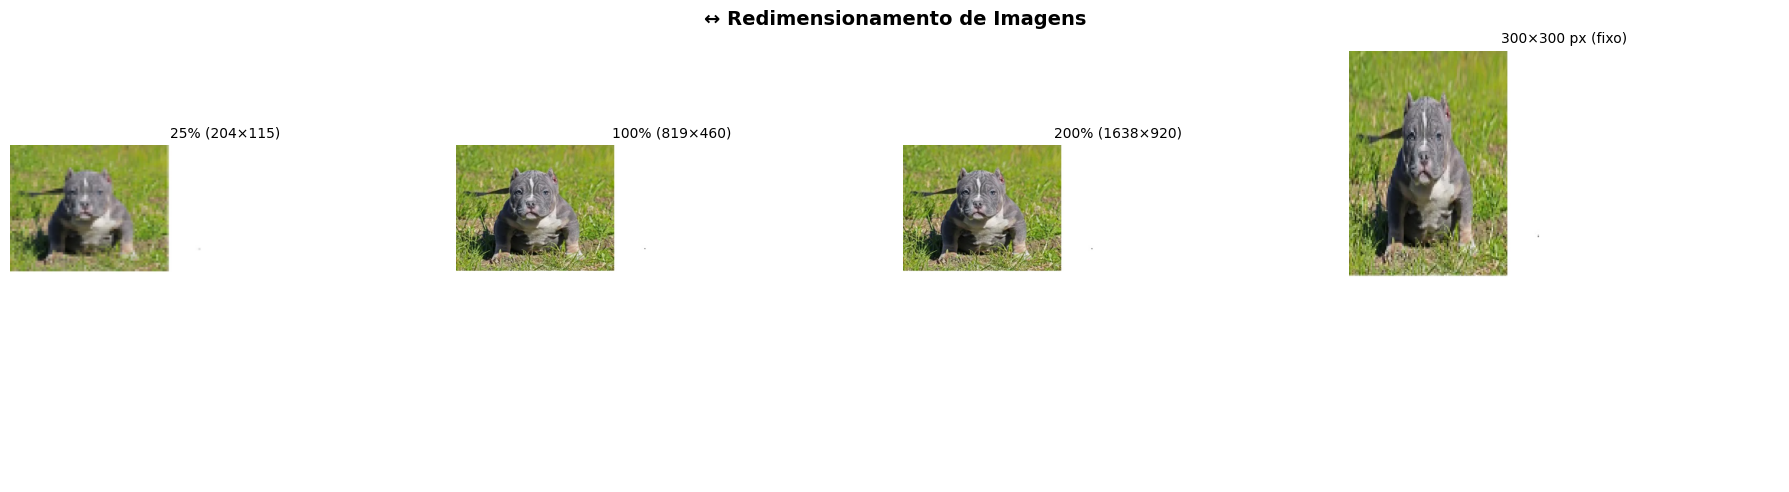

In [ ]:
# ============================================================
# AULA 4 — Célula 1: Redimensionamento
# ============================================================
# cv2.resize() redimensiona a imagem para o tamanho especificado.
# O parâmetro 'interpolation' define o algoritmo de reconstrução:
#   - INTER_NEAREST: mais rápido, menor qualidade (para redução)
#   - INTER_LINEAR : bicubic, boa qualidade (padrão)
#   - INTER_CUBIC  : alta qualidade (para ampliação)
#   - INTER_AREA   : ideal para redução

try:
    img = imagem_bgr.copy()
except NameError:
    img = cv2.imread("imagem_teste.png")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]

# Diferentes tamanhos
img_pequena  = cv2.resize(img_rgb, (w//4, h//4), interpolation=cv2.INTER_AREA)
img_original = img_rgb.copy()
img_grande   = cv2.resize(img_rgb, (w*2, h*2), interpolation=cv2.INTER_CUBIC)
img_fixa     = cv2.resize(img_rgb, (300, 300), interpolation=cv2.INTER_LINEAR)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
configs = [
    (img_pequena,  f'25% ({img_pequena.shape[1]}×{img_pequena.shape[0]})'),
    (img_original, f'100% ({w}×{h})'),
    (img_grande,   f'200% ({img_grande.shape[1]}×{img_grande.shape[0]})'),
    (img_fixa,     '300×300 px (fixo)'),
]

for ax, (im, titulo) in zip(axes, configs):
    ax.imshow(im)
    ax.set_title(titulo, fontsize=10)
    ax.axis('off')

plt.suptitle('↔️ Redimensionamento de Imagens', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_470/2409305129.py:38: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


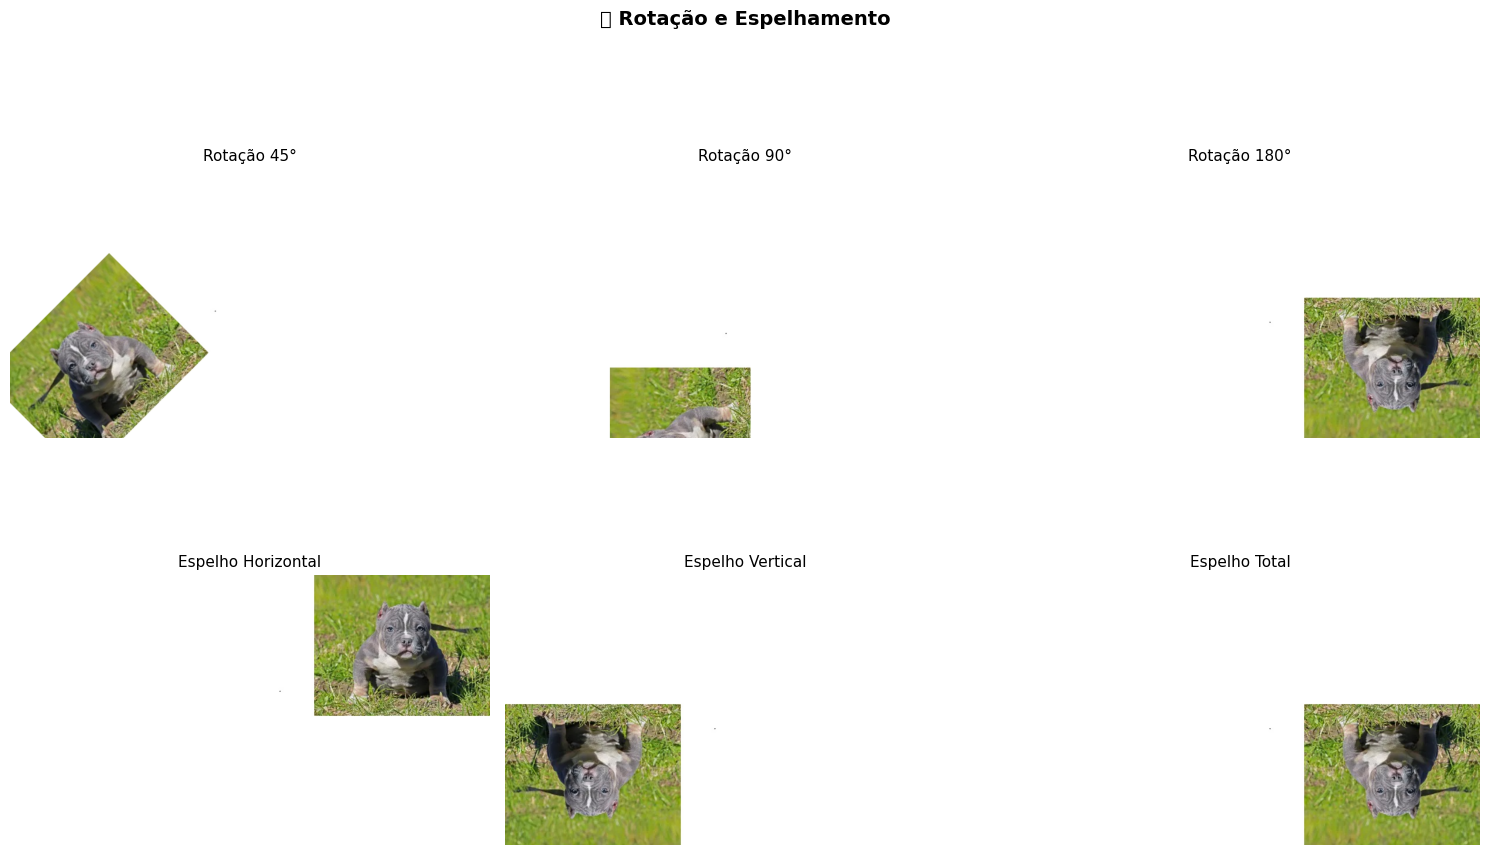

In [ ]:
# ============================================================
# AULA 4 — Célula 2: Rotação e espelhamento
# ============================================================
# A rotação em OpenCV usa uma MATRIZ DE ROTAÇÃO 2D:
#   M = [[cos(θ), -sin(θ), tx],
#        [sin(θ),  cos(θ), ty]]
# onde tx, ty são as translações para manter o centro.

centro = (w//2, h//2)

# Gerando matrizes de rotação
M_45  = cv2.getRotationMatrix2D(centro, 45, 1.0)
M_90  = cv2.getRotationMatrix2D(centro, 90, 1.0)
M_180 = cv2.getRotationMatrix2D(centro, 180, 1.0)

# Aplicando rotações
img_rot45  = cv2.warpAffine(img_rgb, M_45,  (w, h), borderValue=(255,255,255))
img_rot90  = cv2.warpAffine(img_rgb, M_90,  (w, h), borderValue=(255,255,255))
img_rot180 = cv2.warpAffine(img_rgb, M_180, (w, h), borderValue=(255,255,255))

# Espelhamento (flip)
img_espH = cv2.flip(img_rgb, 1)   # Horizontal
img_espV = cv2.flip(img_rgb, 0)   # Vertical
img_espHV = cv2.flip(img_rgb, -1) # Ambos

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

dados_rot = [(img_rot45, 'Rotação 45°'), (img_rot90, 'Rotação 90°'), (img_rot180, 'Rotação 180°')]
dados_flip = [(img_espH, 'Espelho Horizontal'), (img_espV, 'Espelho Vertical'), (img_espHV, 'Espelho Total')]

for ax, (im, titulo) in zip(axes[0], dados_rot):
    ax.imshow(im); ax.set_title(titulo, fontsize=11); ax.axis('off')

for ax, (im, titulo) in zip(axes[1], dados_flip):
    ax.imshow(im); ax.set_title(titulo, fontsize=11); ax.axis('off')

plt.suptitle('🔄 Rotação e Espelhamento', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

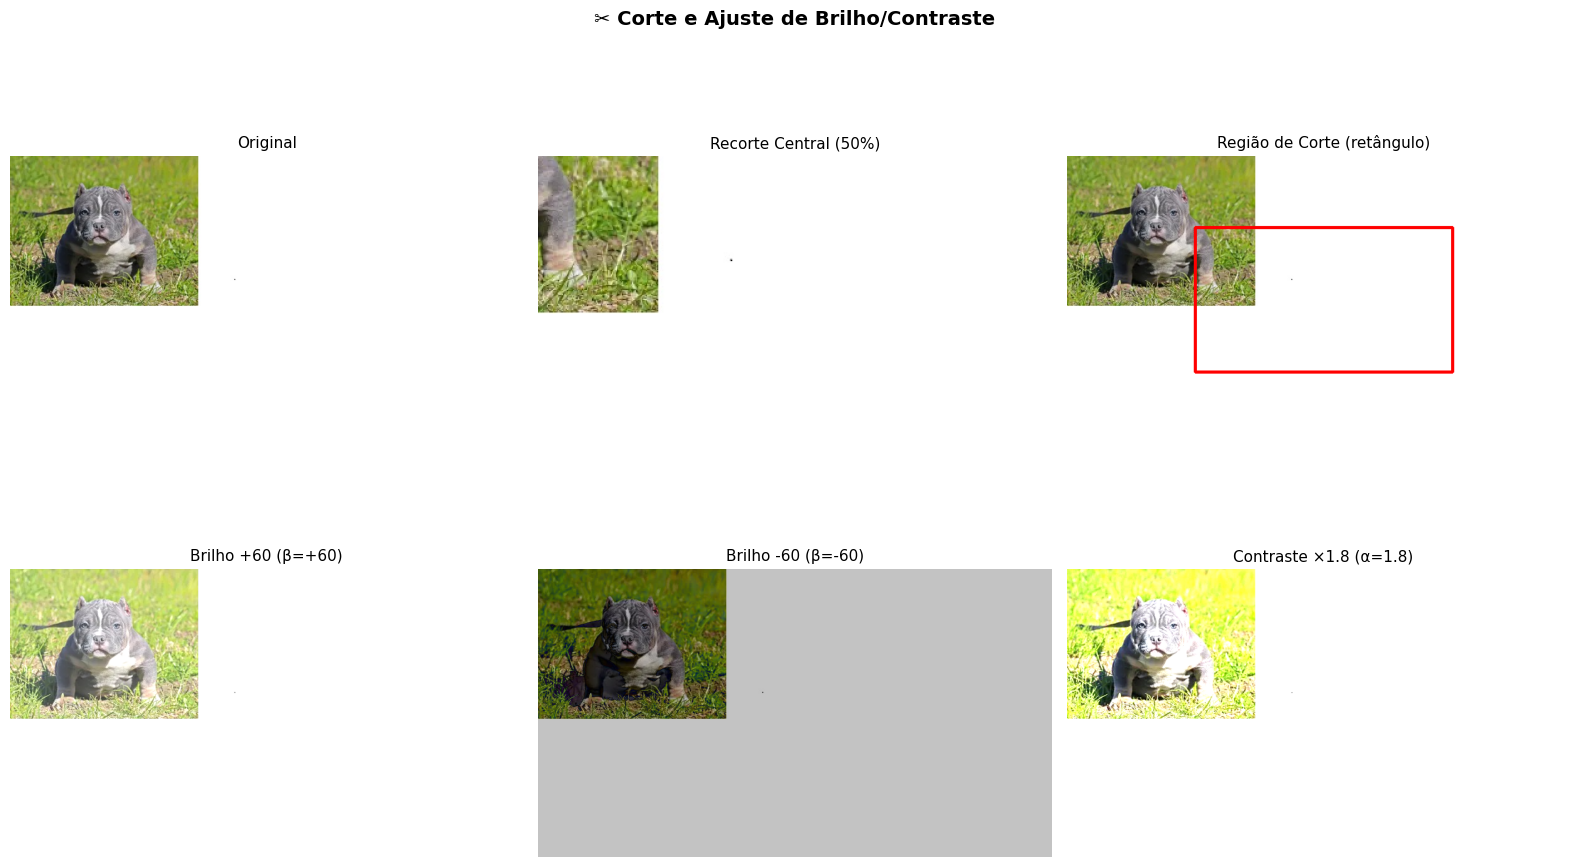

In [ ]:
# ============================================================
# AULA 4 — Célula 3: Corte (crop) e ajuste de brilho/contraste
# ============================================================
# Corte: simplesmente fatiamos (slice) a matriz NumPy
# Ajuste de contraste e brilho: g(x) = α·f(x) + β
#   α > 1 → aumenta contraste
#   β > 0 → aumenta brilho

# Corte central de 50% da imagem
y1, y2 = h//4, 3*h//4
x1, x2 = w//4, 3*w//4
img_crop = img_rgb[y1:y2, x1:x2]

# Ajustes de brilho e contraste usando convertScaleAbs
img_brilho_mais  = cv2.convertScaleAbs(img_rgb, alpha=1.0, beta=60)   # +brilho
img_brilho_menos = cv2.convertScaleAbs(img_rgb, alpha=1.0, beta=-60)  # -brilho
img_contraste    = cv2.convertScaleAbs(img_rgb, alpha=1.8, beta=0)    # +contraste

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

axes[0,0].imshow(img_rgb); axes[0,0].set_title('Original', fontsize=11); axes[0,0].axis('off')
axes[0,1].imshow(img_crop); axes[0,1].set_title('Recorte Central (50%)', fontsize=11); axes[0,1].axis('off')
# Destacar a área de corte na imagem original
img_rect = img_rgb.copy()
cv2.rectangle(img_rect, (x1, y1), (x2, y2), (255, 0, 0), 3)
axes[0,2].imshow(img_rect); axes[0,2].set_title('Região de Corte (retângulo)', fontsize=11); axes[0,2].axis('off')

axes[1,0].imshow(img_brilho_mais); axes[1,0].set_title('Brilho +60 (β=+60)', fontsize=11); axes[1,0].axis('off')
axes[1,1].imshow(img_brilho_menos); axes[1,1].set_title('Brilho -60 (β=-60)', fontsize=11); axes[1,1].axis('off')
axes[1,2].imshow(img_contraste); axes[1,2].set_title('Contraste ×1.8 (α=1.8)', fontsize=11); axes[1,2].axis('off')

plt.suptitle('✂️ Corte e Ajuste de Brilho/Contraste', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
# 📘 AULA 5 — OpenCV: Filtragem de Imagens

## O que é Filtragem?

Filtragem é o processo de **modificar os valores dos pixels** baseando-se em seus vizinhos, usando uma operação matemática chamada **convolução**.

### Convolução 2D
Para cada pixel na posição (i,j), o novo valor é calculado como:

$$g(i,j) = \sum_{m}\sum_{n} f(i-m, j-n) \cdot h(m,n)$$

Onde:
- `f(i,j)` = imagem original
- `h(m,n)` = kernel (máscara de convolução)
- `g(i,j)` = imagem filtrada

O **kernel** define o tipo de filtro aplicado.

/tmp/ipykernel_470/3844875366.py:34: UserWarning: Glyph 127787 (\N{FOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127787 (\N{FOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


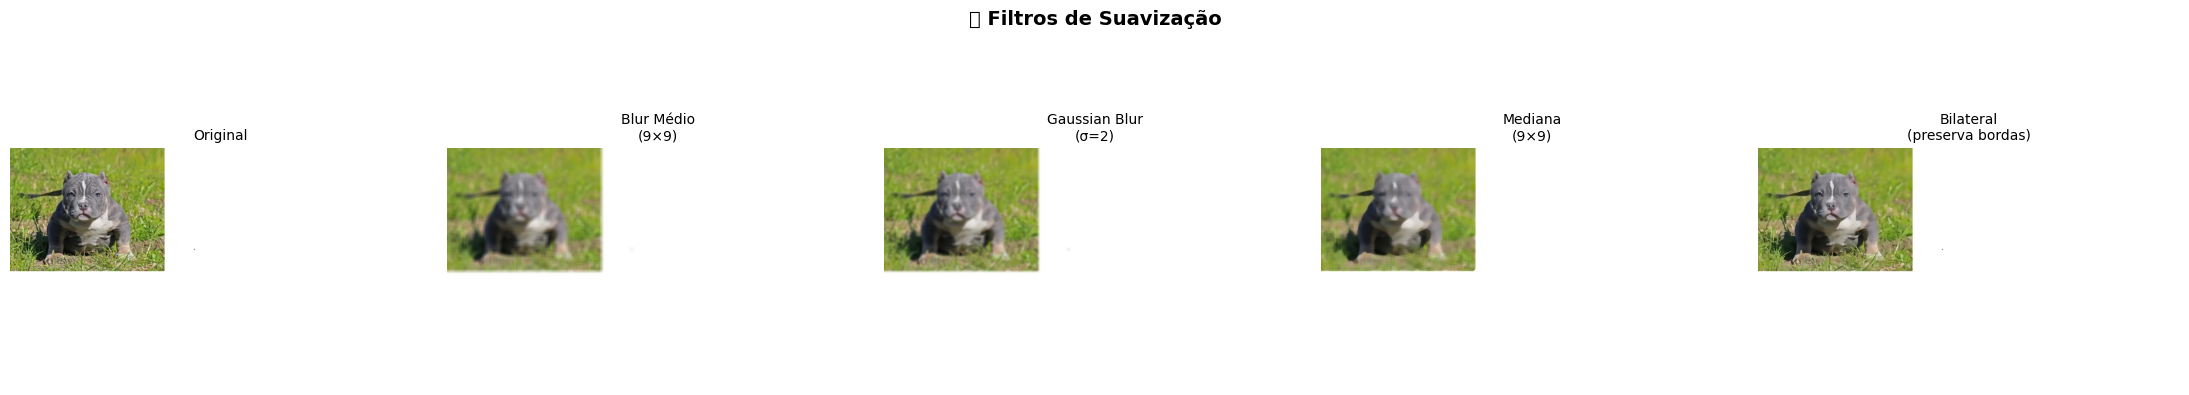


📚 Quando usar cada filtro:
  Blur Médio  → Rápido, para ruídos uniformes
  Gaussian    → Suavização natural, mais usado em pré-processamento
  Mediana     → Ideal para ruído sal-e-pimenta (valores extremos)
  Bilateral   → Quando precisa preservar bordas (ex: segmentação)


In [ ]:
# ============================================================
# AULA 5 — Célula 1: Filtros de suavização (Blur)
# ============================================================
# Filtros de suavização reduzem ruído e detalhes finos.
# São usados como pré-processamento em muitos pipelines.

try:
    img = imagem_bgr.copy()
except NameError:
    img = cv2.imread("imagem_teste.png")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 1. Blur médio — cada pixel = média dos vizinhos no kernel
img_blur_medio = cv2.blur(img_rgb, (9, 9))

# 2. Gaussian Blur — vizinhos mais próximos têm maior peso (distribuição gaussiana)
img_blur_gauss = cv2.GaussianBlur(img_rgb, (9, 9), sigmaX=2)

# 3. Median Blur — substitui pelo valor mediano (excelente para ruído sal e pimenta)
img_blur_mediana = cv2.medianBlur(img_rgb, 9)

# 4. Bilateral Filter — suaviza sem borrar bordas (preserva contornos)
img_bilateral = cv2.bilateralFilter(img_rgb, d=9, sigmaColor=75, sigmaSpace=75)

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
imgs = [img_rgb, img_blur_medio, img_blur_gauss, img_blur_mediana, img_bilateral]
titulos = ['Original', 'Blur Médio\n(9×9)', 'Gaussian Blur\n(σ=2)', 'Mediana\n(9×9)', 'Bilateral\n(preserva bordas)']

for ax, im, titulo in zip(axes, imgs, titulos):
    ax.imshow(im); ax.set_title(titulo, fontsize=10); ax.axis('off')

plt.suptitle('🌫️ Filtros de Suavização', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📚 Quando usar cada filtro:")
print("  Blur Médio  → Rápido, para ruídos uniformes")
print("  Gaussian    → Suavização natural, mais usado em pré-processamento")
print("  Mediana     → Ideal para ruído sal-e-pimenta (valores extremos)")
print("  Bilateral   → Quando precisa preservar bordas (ex: segmentação)")

/tmp/ipykernel_470/159205321.py:33: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


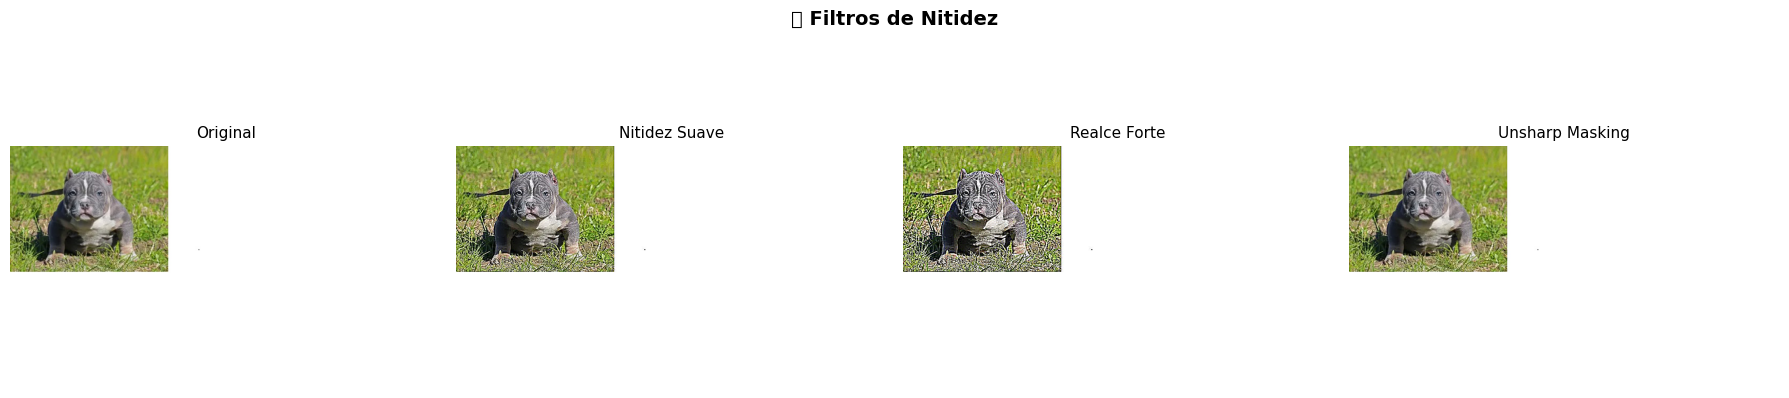


🔬 Visualizando os kernels utilizados:

Kernel de Nitidez Suave:
[[ 0 -1  0]
 [-1  5 -1]
 [ 0 -1  0]]

Kernel de Realce Forte:
[[-1 -1 -1]
 [-1  9 -1]
 [-1 -1 -1]]


In [ ]:
# ============================================================
# AULA 5 — Célula 2: Filtros de nitidez (Sharpening)
# ============================================================
# Filtros de nitidez realçam bordas e detalhes.
# Matematicamente, adicionamos o Laplaciano da imagem.

# Kernel de nitidez: amplifica o pixel central e subtrai vizinhos
kernel_nitidez = np.array([[ 0, -1,  0],
                            [-1,  5, -1],
                            [ 0, -1,  0]])

# Kernel de realce mais agressivo
kernel_realce = np.array([[-1, -1, -1],
                           [-1,  9, -1],
                           [-1, -1, -1]])

img_nitidez = cv2.filter2D(img_rgb, -1, kernel_nitidez)
img_realce  = cv2.filter2D(img_rgb, -1, kernel_realce)

# Unsharp Masking: técnica profissional de nitidez
# Nitidez = Original + α × (Original - Suavizado)
img_blur_leve = cv2.GaussianBlur(img_rgb, (5, 5), sigmaX=1.0)
img_unsharp   = cv2.addWeighted(img_rgb, 1.5, img_blur_leve, -0.5, 0)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
imgs = [img_rgb, img_nitidez, img_realce, img_unsharp]
titulos = ['Original', 'Nitidez Suave', 'Realce Forte', 'Unsharp Masking']

for ax, im, titulo in zip(axes, imgs, titulos):
    ax.imshow(im); ax.set_title(titulo, fontsize=11); ax.axis('off')

plt.suptitle('✨ Filtros de Nitidez', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n🔬 Visualizando os kernels utilizados:")
print("\nKernel de Nitidez Suave:")
print(kernel_nitidez)
print("\nKernel de Realce Forte:")
print(kernel_realce)

---
# 📘 AULA 6 — OpenCV: Detecção de Bordas

## O que são Bordas?

Bordas são regiões onde a **intensidade dos pixels muda bruscamente**. Matematicamente, correspondem a grandes valores do **gradiente** da imagem.

### Gradiente de uma Imagem
O gradiente indica a taxa de variação de intensidade:
- $G_x = \partial I / \partial x$ → variação horizontal
- $G_y = \partial I / \partial y$ → variação vertical  
- $|G| = \sqrt{G_x^2 + G_y^2}$ → magnitude total do gradiente

### Algoritmos Disponíveis
- **Sobel**: Calcula gradiente em x e y separadamente
- **Laplaciano**: Derivada de segunda ordem (mais sensível a ruído)
- **Canny**: Pipeline completo: suavização → gradiente → NMS → limiarização dupla

/tmp/ipykernel_470/3840096835.py:42: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


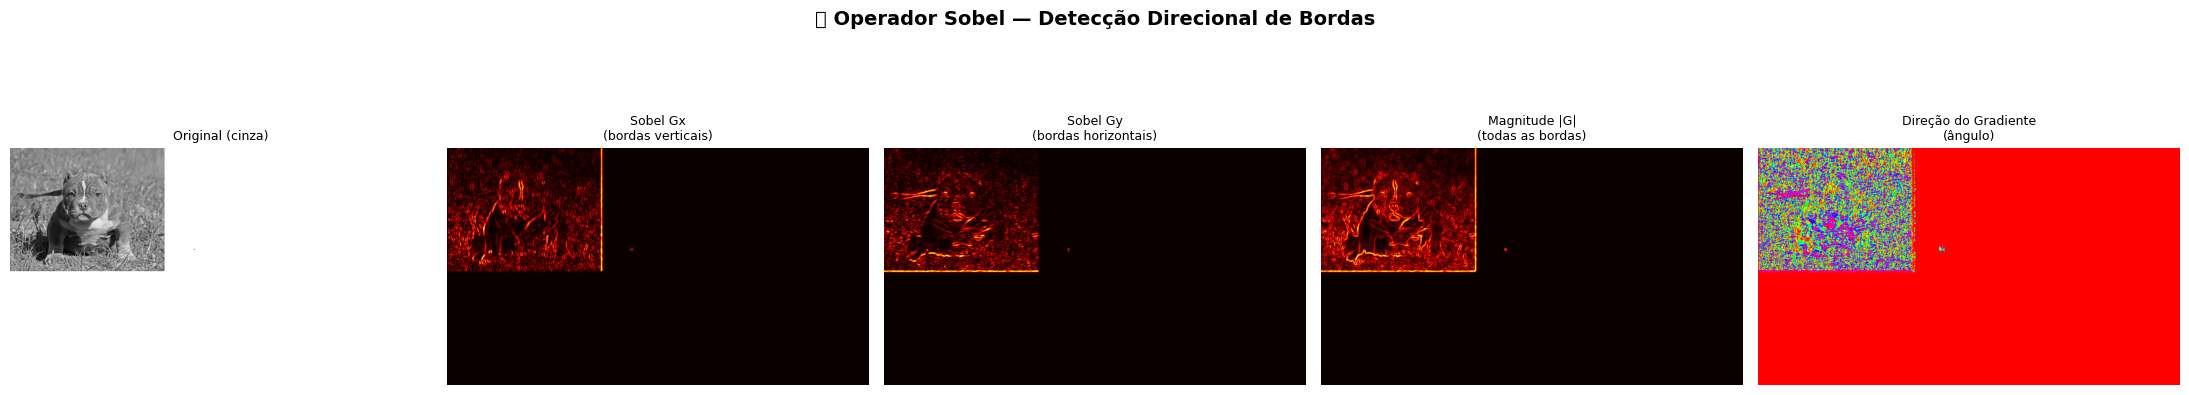

In [ ]:
# ============================================================
# AULA 6 — Célula 1: Operador Sobel
# ============================================================
# Sobel usa dois kernels 3×3 para calcular gradientes direcionais:
#   Gx = [[-1,0,1],[-2,0,2],[-1,0,1]] → detecta bordas verticais
#   Gy = [[-1,-2,-1],[0,0,0],[1,2,1]] → detecta bordas horizontais

try:
    img = imagem_bgr.copy()
except NameError:
    img = cv2.imread("imagem_teste.png")

img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Pré-processamento: suavização para reduzir ruído antes da detecção
img_suavizada = cv2.GaussianBlur(img_gray, (5, 5), 0)

# Operador Sobel — gradientes direcionais
sobel_x = cv2.Sobel(img_suavizada, cv2.CV_64F, 1, 0, ksize=3)  # Bordas verticais
sobel_y = cv2.Sobel(img_suavizada, cv2.CV_64F, 0, 1, ksize=3)  # Bordas horizontais

# Magnitude total do gradiente
sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)
sobel_mag = cv2.normalize(sobel_mag, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

# Direção do gradiente (ângulo)
sobel_dir = np.arctan2(np.abs(sobel_y), np.abs(sobel_x)) * 180 / np.pi

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
dados = [
    (img_gray, 'gray', 'Original (cinza)'),
    (np.abs(sobel_x), 'hot', 'Sobel Gx\n(bordas verticais)'),
    (np.abs(sobel_y), 'hot', 'Sobel Gy\n(bordas horizontais)'),
    (sobel_mag, 'hot', 'Magnitude |G|\n(todas as bordas)'),
    (sobel_dir, 'hsv', 'Direção do Gradiente\n(ângulo)'),
]

for ax, (im, cmap, titulo) in zip(axes, dados):
    ax.imshow(im, cmap=cmap); ax.set_title(titulo, fontsize=9); ax.axis('off')

plt.suptitle('📐 Operador Sobel — Detecção Direcional de Bordas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_470/523054161.py:33: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


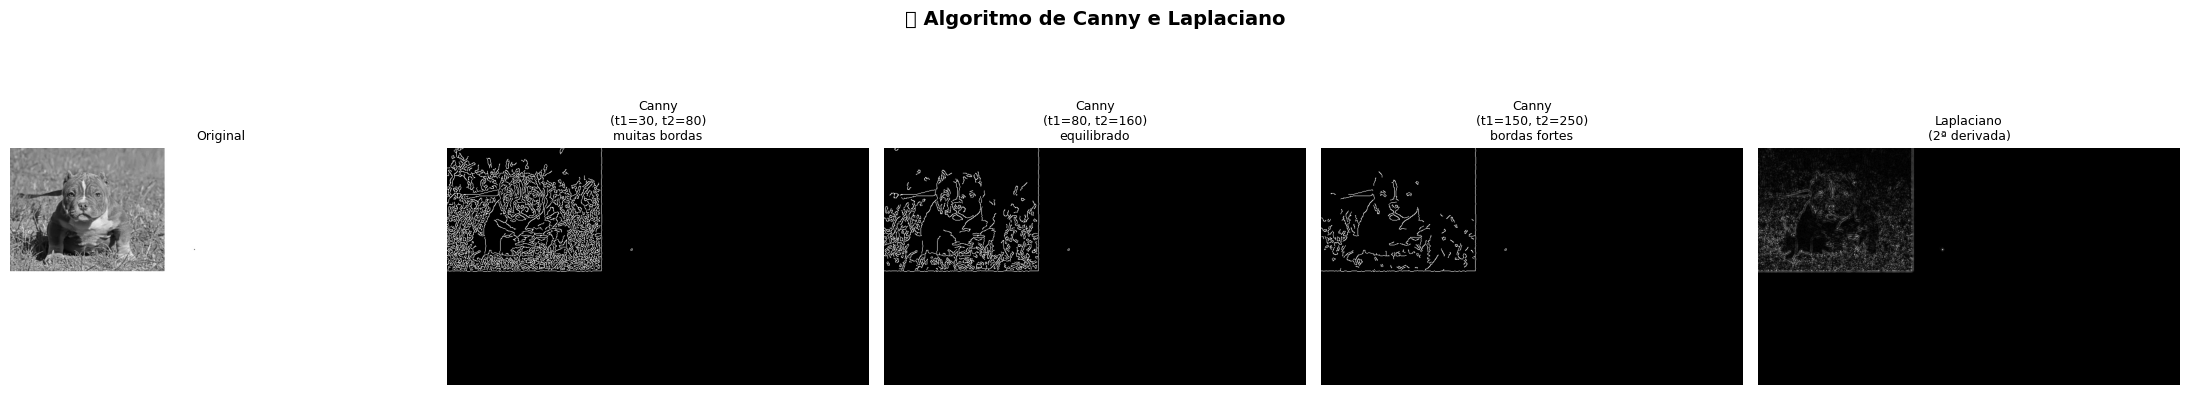


💡 Dica prática para ajustar os limiares do Canny:
  1. Comece com threshold1 = σ × 0.66 e threshold2 = σ × 1.33
  2. Use a regra: threshold2 ≈ 2-3 × threshold1
  3. Ajuste visualmente conforme o resultado desejado


In [ ]:
# ============================================================
# AULA 6 — Célula 2: Algoritmo de Canny
# ============================================================
# Canny é considerado o detector de bordas mais robusto.
# Pipeline: Suavização → Gradiente → NMS → Limiarização dupla → Histerese
#
# Parâmetros críticos:
#   threshold1: limiar inferior (pixels abaixo são descartados)
#   threshold2: limiar superior (pixels acima são bordas certas)
#   Pixels entre os limiares: incluídos se conectados a borda certa

canny_baixo    = cv2.Canny(img_suavizada, threshold1=30,  threshold2=80)
canny_medio    = cv2.Canny(img_suavizada, threshold1=80,  threshold2=160)
canny_alto     = cv2.Canny(img_suavizada, threshold1=150, threshold2=250)

# Laplaciano (derivada de segunda ordem)
laplaciano = cv2.Laplacian(img_suavizada, cv2.CV_64F)
laplaciano_abs = cv2.convertScaleAbs(laplaciano)

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
dados = [
    (img_gray, 'gray', 'Original'),
    (canny_baixo,     'gray', 'Canny\n(t1=30, t2=80)\nmuitas bordas'),
    (canny_medio,     'gray', 'Canny\n(t1=80, t2=160)\nequilibrado'),
    (canny_alto,      'gray', 'Canny\n(t1=150, t2=250)\nbordas fortes'),
    (laplaciano_abs,  'gray', 'Laplaciano\n(2ª derivada)'),
]

for ax, (im, cmap, titulo) in zip(axes, dados):
    ax.imshow(im, cmap=cmap); ax.set_title(titulo, fontsize=9); ax.axis('off')

plt.suptitle('🔍 Algoritmo de Canny e Laplaciano', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 Dica prática para ajustar os limiares do Canny:")
print("  1. Comece com threshold1 = σ × 0.66 e threshold2 = σ × 1.33")
print("  2. Use a regra: threshold2 ≈ 2-3 × threshold1")
print("  3. Ajuste visualmente conforme o resultado desejado")

---
# 📘 AULA 7 — OpenCV: Reconhecimento de Objetos

## Haar Cascades — Detecção Clássica

O método de detecção usando **Haar Cascades** foi proposto por Viola e Jones (2001) e funciona em 3 etapas:
1. **Features Haar**: características simples baseadas em diferenças de intensidade entre regiões
2. **AdaBoost**: seleciona as features mais relevantes
3. **Cascade**: classifica regiões rapidamente descartando falsos positivos

OpenCV oferece classificadores pré-treinados para faces, olhos, corpos, etc.

In [ ]:
# ============================================================
# AULA 7 — Célula 1: Detecção de faces com Haar Cascade
# ============================================================


# URL estável do repositório oficial do OpenCV (Lena é o padrão da computação)
url_face = "https://raw.githubusercontent.com/opencv/opencv/4.x/samples/data/lena.jpg"

def carregar_imagem():
    # 1. Tentar baixar a imagem oficial de teste
    try:
        headers = {'User-Agent': 'Mozilla/5.0'}
        req = urllib.request.Request(url_face, headers=headers)
        with urllib.request.urlopen(req) as response, open("faces_teste.jpg", 'wb') as out_file:
            out_file.write(response.read())
        return cv2.imread("faces_teste.jpg")
    except Exception as e:
        print(f"ℹ️ Não foi possível baixar a imagem externa ({e})")

    # 2. Fallback: Usar a imagem carregada pelo usuário na Aula 2
    try:
        return imagem_bgr.copy()
    except NameError:
        print("❌ Nenhuma imagem encontrada. Por favor, execute a Aula 2.")
        return None

img_face = carregar_imagem()

if img_face is not None:
    # Carregando os classificadores pré-treinados do OpenCV
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    eye_cascade  = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')

    img_face_gray = cv2.cvtColor(img_face, cv2.COLOR_BGR2GRAY)
    img_face_rgb  = cv2.cvtColor(img_face, cv2.COLOR_BGR2RGB)

    # Detecção: scaleFactor=1.1, minNeighbors=5
    faces = face_cascade.detectMultiScale(img_face_gray, 1.1, 5, minSize=(30, 30))

    img_resultado = img_face_rgb.copy()
    print(f"👤 Faces detectadas: {len(faces)}")

    for (x, y, w, h) in faces:
        # Desenha retângulo na face
        cv2.rectangle(img_resultado, (x, y), (x+w, y+h), (0, 255, 0), 3)

        # Região de interesse para detectar olhos dentro da face
        roi_gray = img_face_gray[y:y+h, x:x+w]
        roi_rgb  = img_resultado[y:y+h, x:x+w]
        olhos = eye_cascade.detectMultiScale(roi_gray)
        for (ex, ey, ew, eh) in olhos:
            cv2.rectangle(roi_rgb, (ex, ey), (ex+ew, ey+eh), (255, 0, 0), 2)

    fig, axes = plt.subplots(1, 2, figsize=(12, 7))
    axes[0].imshow(img_face_rgb); axes[0].set_title('Imagem Original'); axes[0].axis('off')
    axes[1].imshow(img_resultado); axes[1].set_title(f'Detecção: {len(faces)} face(s)'); axes[1].axis('off')
    plt.show()
else:
    print("Não foi possível processar. Carregue uma imagem na Aula 2.")

In [ ]:
# ============================================================
# AULA 7 — Célula 2: Detecção por cor (segmentação HSV)
# ============================================================
# Outra abordagem de detecção: identificar objetos por cor.
# O espaço HSV é ideal porque separa a COR (Hue) da LUMINOSIDADE.

try:
    img = imagem_bgr.copy()
except NameError:
    img = cv2.imread("imagem_teste.png")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Definindo faixa de cores a detectar (exemplo: tons de azul)
# Hue no OpenCV vai de 0 a 179 (equivale a 0-360° dividido por 2)
# Tabela de Hue: Vermelho≈0, Laranja≈15, Amarelo≈30, Verde≈60, Azul≈120, Violeta≈150

# Tons de azul (H: 100-140)
lower_blue = np.array([100, 50, 50])
upper_blue = np.array([140, 255, 255])
mask_blue  = cv2.inRange(img_hsv, lower_blue, upper_blue)

# Tons de verde (H: 35-85)
lower_green = np.array([35, 40, 40])
upper_green = np.array([85, 255, 255])
mask_green  = cv2.inRange(img_hsv, lower_green, upper_green)

# Aplicando as máscaras
result_blue  = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_blue)
result_green = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_green)

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
dados = [
    (img_rgb,    None,   'Original'),
    (mask_blue,  'gray', 'Máscara Azul'),
    (result_blue, None,  'Resultado Azul'),
    (mask_green, 'gray', 'Máscara Verde'),
    (result_green, None, 'Resultado Verde'),
]

for ax, (im, cmap, titulo) in zip(axes, dados):
    ax.imshow(im, cmap=cmap); ax.set_title(titulo, fontsize=11); ax.axis('off')

plt.suptitle('🎨 Segmentação por Cor no Espaço HSV', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📌 Dica: Ajuste os intervalos de HSV para detectar a cor desejada:")
print("  Vermelho : H=[0-10] ou H=[170-179]")
print("  Laranja  : H=[10-25]")
print("  Amarelo  : H=[25-35]")
print("  Verde    : H=[35-85]")
print("  Azul     : H=[100-140]")
print("  Violeta  : H=[140-170]")

---
# 📘 AULA 8 — SciPy: Processamento de Sinais

## Por que SciPy para Imagens?

Uma imagem digital pode ser tratada como um **sinal 2D**, onde:
- Os eixos x e y representam posição espacial
- A amplitude representa intensidade de luz

O módulo `scipy.ndimage` oferece ferramentas poderosas para processamento de imagens N-dimensionais, enquanto `scipy.fft` permite análise no domínio da frequência.

### Domínio da Frequência
A **Transformada de Fourier** decompõe a imagem em componentes de frequência:
- **Baixas frequências**: variações suaves (fundo, gradientes)
- **Altas frequências**: variações bruscas (bordas, ruído, detalhes)

Filtrar no domínio da frequência é equivalente a convoluir no domínio espacial!

In [ ]:
# ============================================================
# AULA 8 — Célula 1: Transformada de Fourier 2D
# ============================================================

from scipy import ndimage, fft
import scipy.signal as signal

try:
    img = imagem_bgr.copy()
except NameError:
    img = cv2.imread("imagem_teste.png")

img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(float)

# Calculando a Transformada de Fourier 2D
f_transform = fft.fft2(img_gray)

# Centralizando: coloca as baixas frequências no centro da imagem
f_shift = fft.fftshift(f_transform)

# Espectro de magnitude (escala logarítmica para melhor visualização)
magnitude_spectrum = np.log(np.abs(f_shift) + 1)

# Espectro de fase
phase_spectrum = np.angle(f_shift)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(img_gray, cmap='gray')
axes[0].set_title('Imagem Original\n(domínio espacial)', fontsize=11)
axes[0].axis('off')

im1 = axes[1].imshow(magnitude_spectrum, cmap='inferno')
axes[1].set_title('Espectro de Magnitude\n(domínio da frequência)', fontsize=11)
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(phase_spectrum, cmap='twilight')
axes[2].set_title('Espectro de Fase\n(informação de estrutura)', fontsize=11)
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.suptitle('🌊 Transformada de Fourier 2D', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📚 Interpretando o espectro de magnitude:")
print("  Centro do espectro → baixas frequências (variações lentas, fundo)")
print("  Bordas do espectro → altas frequências (bordas, ruído, detalhes finos)")
print("  Linhas brilhantes  → padrões repetitivos na imagem")

In [ ]:
# ============================================================
# AULA 8 — Célula 2: Filtragem no domínio da frequência
# ============================================================
# Filtramos o espectro de Fourier para remover componentes indesejados.
# Filtro passa-baixa: mantém centro (baixas freq) → suaviza a imagem
# Filtro passa-alta: mantém bordas (altas freq) → detecta contornos

h, w = img_gray.shape
cy, cx = h//2, w//2  # Centro do espectro

# Criando máscara circular
Y, X = np.ogrid[:h, :w]
dist_do_centro = np.sqrt((X - cx)**2 + (Y - cy)**2)

raio = min(h, w) // 8  # Raio do filtro

# Filtro passa-baixa (mantém frequências dentro do raio)
mascara_pb = (dist_do_centro <= raio).astype(float)

# Filtro passa-alta (remove frequências dentro do raio)
mascara_pa = (dist_do_centro > raio).astype(float)

# Aplicando filtros
f_pb = f_shift * mascara_pb
f_pa = f_shift * mascara_pa

# Transformada Inversa de Fourier (volta para o domínio espacial)
img_filtrada_pb = np.abs(fft.ifft2(fft.ifftshift(f_pb)))
img_filtrada_pa = np.abs(fft.ifft2(fft.ifftshift(f_pa)))

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

axes[0,0].imshow(img_gray, cmap='gray'); axes[0,0].set_title('Original'); axes[0,0].axis('off')
axes[0,1].imshow(np.log(np.abs(f_pb)+1), cmap='inferno'); axes[0,1].set_title(f'Espectro PB (raio={raio})'); axes[0,1].axis('off')
axes[0,2].imshow(img_filtrada_pb, cmap='gray'); axes[0,2].set_title('Resultado PB\n(suavização)'); axes[0,2].axis('off')

axes[1,0].imshow(img_gray, cmap='gray'); axes[1,0].set_title('Original'); axes[1,0].axis('off')
axes[1,1].imshow(np.log(np.abs(f_pa)+1), cmap='inferno'); axes[1,1].set_title(f'Espectro PA (raio={raio})'); axes[1,1].axis('off')
axes[1,2].imshow(img_filtrada_pa, cmap='gray'); axes[1,2].set_title('Resultado PA\n(realce de bordas)'); axes[1,2].axis('off')

plt.suptitle('🔊 Filtragem no Domínio da Frequência (SciPy FFT)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
# 📘 AULA 9 — SciPy: Interpolação de Imagens

## O que é Interpolação?

Interpolação é o processo de **estimar valores desconhecidos** entre pontos conhecidos. Em imagens, é usada quando:
- **Redimensionamos** uma imagem (precisamos criar ou combinar pixels)
- **Rotacionamos** uma imagem (pixels ficam em posições não-inteiras)
- **Corrigimos distorções** geométricas

### Métodos de Interpolação
| Ordem | Método | Qualidade | Velocidade |
|-------|--------|-----------|------------|
| 0 | Vizinho mais próximo | Baixa | Muito rápido |
| 1 | Bilinear | Média | Rápido |
| 3 | Bicúbica (padrão) | Alta | Médio |
| 5 | B-Spline | Muito alta | Lento |

In [ ]:
# ============================================================
# AULA 9 — Célula 1: Comparação de métodos de interpolação
# ============================================================

from scipy.ndimage import zoom, rotate as scipy_rotate

try:
    img = imagem_bgr.copy()
except NameError:
    img = cv2.imread("imagem_teste.png")

img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(float) / 255.0

# Reduzindo para 25% e depois ampliando — evidencia a interpolação
fator = 0.25

# Ordem 0: Vizinho mais próximo — pixel mais próximo é usado
img_pequena = zoom(img_gray, fator, order=0)
zoom_factor_back = 1.0 / fator

img_viz_prox  = zoom(img_pequena, zoom_factor_back, order=0)  # Efeito pixelizado
img_bilinear  = zoom(img_pequena, zoom_factor_back, order=1)  # Suave mas menos nítido
img_bicubica  = zoom(img_pequena, zoom_factor_back, order=3)  # Boa qualidade
img_bspline   = zoom(img_pequena, zoom_factor_back, order=5)  # Alta qualidade

# Garantindo mesmo tamanho para comparação
h_orig, w_orig = img_gray.shape
imgs_interp = [img_viz_prox, img_bilinear, img_bicubica, img_bspline]
imgs_interp = [im[:h_orig, :w_orig] for im in imgs_interp]

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
titulos = ['Original', 'Vizinho Mais\nPróximo (O=0)', 'Bilinear (O=1)', 'Bicúbica (O=3)', 'B-Spline (O=5)']
todas_imgs = [img_gray] + imgs_interp

for ax, im, titulo in zip(axes, todas_imgs, titulos):
    ax.imshow(im, cmap='gray'); ax.set_title(titulo, fontsize=10); ax.axis('off')

plt.suptitle('🔍 Comparação de Métodos de Interpolação (Zoom 25% → 100%)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 Qualidade dos métodos (escala subjetiva):")
print("  Vizinho Mais Próximo : efeito 'LEGO'/pixelizado — útil para imagens binárias")
print("  Bilinear             : suave mas pode parecer borrado")
print("  Bicúbica             : melhor equilíbrio qualidade/desempenho ← RECOMENDADO")
print("  B-Spline (ordem 5)   : mais suave, mas pode introduzir artefatos ondulados")

In [ ]:
# ============================================================
# AULA 9 — Célula 2: Rotação com interpolação SciPy
# ============================================================
# scipy.ndimage.rotate oferece controle fino sobre interpolação
# durante a rotação, preservando melhor a qualidade.

angulos = [15, 30, 45, 90]
fig, axes = plt.subplots(1, len(angulos)+1, figsize=(20, 5))

axes[0].imshow(img_gray, cmap='gray')
axes[0].set_title('Original', fontsize=11)
axes[0].axis('off')

for ax, ang in zip(axes[1:], angulos):
    # reshape=True: ajusta o tamanho para não cortar a imagem
    # order=3: interpolação bicúbica
    img_rotada = scipy_rotate(img_gray, ang, reshape=True, order=3, cval=0.5)
    ax.imshow(img_rotada, cmap='gray')
    ax.set_title(f'Rotação {ang}°\n(bicúbica, reshape=True)', fontsize=10)
    ax.axis('off')

plt.suptitle('🔄 Rotação com Interpolação Bicúbica (SciPy)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
# 📘 AULA 10 — SciPy: Análise Estatística Visual

## Estatística Aplicada a Imagens

A análise estatística de imagens permite:
- **Descrever** a distribuição de intensidades (média, desvio, curtose)
- **Comparar** imagens antes e após processamento
- **Detectar anomalias** ou regiões de interesse
- **Avaliar qualidade** de algoritmos de processamento

Métricas importantes em visão computacional:
- **PSNR** (Peak Signal-to-Noise Ratio): qualidade de reconstrução
- **SSIM** (Structural Similarity Index): similaridade perceptual
- **Entropia**: mede a informação/complexidade da imagem

In [ ]:
# ============================================================
# AULA 10 — Célula 1: Estatísticas descritivas
# ============================================================

from scipy import stats

try:
    img = imagem_bgr.copy()
except NameError:
    img = cv2.imread("imagem_teste.png")

img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
pixels = img_gray.flatten().astype(float)

# Calculando estatísticas
media        = np.mean(pixels)
mediana      = np.median(pixels)
desvio_pad   = np.std(pixels)
assimetria   = stats.skew(pixels)
curtose      = stats.kurtosis(pixels)
entropia_val = stats.entropy(np.histogram(pixels, bins=256, range=(0,256))[0] + 1e-10)

print("📊 ESTATÍSTICAS DESCRITIVAS DA IMAGEM")
print("=" * 40)
print(f"  Média (brilho médio)   : {media:.2f}")
print(f"  Mediana                : {mediana:.2f}")
print(f"  Desvio padrão          : {desvio_pad:.2f}")
print(f"  Mínimo / Máximo        : {pixels.min():.0f} / {pixels.max():.0f}")
print(f"  Assimetria (skewness)  : {assimetria:.4f}")
print(f"  Curtose (kurtosis)     : {curtose:.4f}")
print(f"  Entropia               : {entropia_val:.4f}")

print("\n📖 Interpretações:")
if media < 85:
    print("  → Imagem escura (média baixa)")
elif media > 170:
    print("  → Imagem clara (média alta)")
else:
    print("  → Imagem com bom brilho geral")

if assimetria > 0.5:
    print("  → Distribuição assimétrica positiva (mais pixels escuros)")
elif assimetria < -0.5:
    print("  → Distribuição assimétrica negativa (mais pixels claros)")
else:
    print("  → Distribuição aproximadamente simétrica")

# Visualizando
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(img_gray, cmap='gray')
axes[0].set_title('Imagem em Escala de Cinza', fontsize=11)
axes[0].axis('off')

axes[1].hist(pixels, bins=64, color='steelblue', edgecolor='none', alpha=0.8)
axes[1].axvline(media, color='red', linestyle='--', linewidth=2, label=f'Média={media:.1f}')
axes[1].axvline(mediana, color='green', linestyle=':', linewidth=2, label=f'Mediana={mediana:.1f}')
axes[1].set_title('Histograma com Estatísticas', fontsize=11)
axes[1].set_xlabel('Intensidade do pixel')
axes[1].set_ylabel('Frequência')
axes[1].legend()

# Box plot por canal de cor
canais = {'Azul': img[:,:,0].flatten(),
          'Verde': img[:,:,1].flatten(),
          'Vermelho': img[:,:,2].flatten()}

axes[2].boxplot(canais.values(), labels=canais.keys(),
                patch_artist=True,
                boxprops=dict(facecolor='lightblue'),
                medianprops=dict(color='red', linewidth=2))
axes[2].set_title('Box Plot por Canal de Cor', fontsize=11)
axes[2].set_ylabel('Valor do pixel')
axes[2].set_ylim([0, 255])

plt.suptitle('📊 Análise Estatística da Imagem', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# AULA 10 — Célula 2: Métricas de qualidade (PSNR e Equalização)
# ============================================================
# PSNR (Peak Signal-to-Noise Ratio) mede a qualidade de uma
# imagem processada em relação à original.
# PSNR > 40 dB → excelente qualidade
# PSNR 30-40 dB → boa qualidade (aceitável)
# PSNR < 30 dB → qualidade degradada

def calcular_psnr(img_original, img_processada):
    """Calcula o Peak Signal-to-Noise Ratio entre duas imagens."""
    mse = np.mean((img_original.astype(float) - img_processada.astype(float))**2)
    if mse == 0:
        return float('inf')
    return 20 * np.log10(255.0 / np.sqrt(mse))

# Equalização de histograma — melhora o contraste redistribuindo intensidades
img_equalizada = cv2.equalizeHist(img_gray)

# Equalização adaptativa (CLAHE) — mais suave, preserva detalhes locais
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
img_clahe = clahe.apply(img_gray)

# Calculando PSNR
psnr_eq   = calcular_psnr(img_gray, img_equalizada)
psnr_clahe = calcular_psnr(img_gray, img_clahe)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Linha superior: imagens
axes[0,0].imshow(img_gray, cmap='gray'); axes[0,0].set_title('Original', fontsize=11); axes[0,0].axis('off')
axes[0,1].imshow(img_equalizada, cmap='gray')
axes[0,1].set_title(f'Equalização Global\nPSNR={psnr_eq:.2f} dB', fontsize=11); axes[0,1].axis('off')
axes[0,2].imshow(img_clahe, cmap='gray')
axes[0,2].set_title(f'CLAHE (adaptativo)\nPSNR={psnr_clahe:.2f} dB', fontsize=11); axes[0,2].axis('off')

# Linha inferior: histogramas correspondentes
for ax, im, titulo, cor in zip(
    axes[1],
    [img_gray, img_equalizada, img_clahe],
    ['Histograma Original', 'Histograma Equalizado', 'Histograma CLAHE'],
    ['steelblue', 'tomato', 'seagreen']):
    ax.hist(im.flatten(), bins=64, color=cor, alpha=0.8, edgecolor='none')
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel('Intensidade')
    ax.set_ylabel('Frequência')
    ax.set_xlim([0, 255])

plt.suptitle('📈 Equalização de Histograma e Métricas de Qualidade', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n🎯 Resumo das métricas:")
print(f"  PSNR Equalização Global : {psnr_eq:.2f} dB")
print(f"  PSNR CLAHE              : {psnr_clahe:.2f} dB")
print("\n💡 CLAHE tende a ter PSNR maior (menos distorção) que a equalização global,")
print("   porque adapta o contraste localmente, sem saturar regiões já bem iluminadas.")

In [ ]:
# ============================================================
# AULA 10 — Célula 3: Resumo e próximos passos
# ============================================================

print("""╔══════════════════════════════════════════════════════════════╗
║         RESUMO DO NOTEBOOK — PROCESSAMENTO DE IMAGENS         ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  ✅ Aula 1  - Bibliotecas e conceito de imagem como matriz  ║
║  ✅ Aula 2  - Upload e inspeção de imagens                   ║
║  ✅ Aula 3  - OpenCV: leitura, escrita e espaços de cor      ║
║  ✅ Aula 4  - OpenCV: redimensionamento, rotação e recorte   ║
║  ✅ Aula 5  - OpenCV: filtros de suavização e nitidez        ║
║  ✅ Aula 6  - OpenCV: detecção de bordas (Canny, Sobel)      ║
║  ✅ Aula 7  - OpenCV: reconhecimento de objetos (Haar, HSV)  ║
║  ✅ Aula 8  - SciPy: Transformada de Fourier e filtragem     ║
║  ✅ Aula 9  - SciPy: interpolação e zoom com qualidade       ║
║  ✅ Aula 10 - SciPy: análise estatística e métricas          ║
║                                                              ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  🔗 Recursos adicionais:                                     ║
║     → docs.opencv.org                                        ║
║     → docs.scipy.org/doc/scipy/reference/ndimage.html        ║
║     → scikit-image.org/docs/stable/auto_examples             ║
╚══════════════════════════════════════════════════════════════╝""")